In [50]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [51]:
dados = pd.read_csv(r'C:\Users\ashto\OneDrive\Documents\Python_\Cálculo_Numérico\Grupo02 (1).csv', sep =';')
dados['Precipitação'] = dados['Precipitação'].str.replace(',','.').astype(float)
dados

,Mês,Precipitação
0,1,144.4
1,2,150.0
2,3,125.8
3,4,94.0
4,5,111.0
5,6,262.2
6,7,149.8
7,8,186.0
8,9,188.4
9,10,231.3


In [52]:
x_dados = dados['Mês']
y_dados = dados['Precipitação']

In [53]:
# x => mês
# A0, A1, B1 coeficientes

def modelo_trigonometrico(x, A0, A1, B1):
    """
    período fixo em 12 meses
    """
    
    return A0 + A1*np.cos(2*np.pi * x /12) + B1 *np.sin(2*np.pi *x /12)


# curve_fit usa o metodo dos minimos quadrados para encontrar os melhores coeficientes A0, A1, B1
# `popt` conterá os coeficientes ótimos [A0, A1, B1]
# `pcov` é a matriz de covariância, que pode ser usada para calcular a incerteza dos parâmetros.
params_otimos, pcov = curve_fit(modelo_trigonometrico, x_dados, y_dados)

A0_fit, A1_fit, B1_fit = params_otimos
print("--- Coeficientes Encontrados ---")
print(f"A0 (Média de precipitação ajustada): {A0_fit:.2f}")
print(f"A1 (Coeficiente do cosseno): {A1_fit:.2f}")
print(f"B1 (Coeficiente do seno): {B1_fit:.2f}")
print("\nFunção final F(x) = {:.2f} + {:.2f}*cos(2*pi*x/12) + {:.2f}*sin(2*pi*x/12)".format(A0_fit, A1_fit, B1_fit))

--- Coeficientes Encontrados ---
A0 (Média de precipitação ajustada): 133.36
A1 (Coeficiente do cosseno): 28.24
B1 (Coeficiente do seno): -60.72

Função final F(x) = 133.36 + 28.24*cos(2*pi*x/12) + -60.72*sin(2*pi*x/12)



--- Previsão ---
A precipitação estimada para o mês 72 é: 161.60 mm


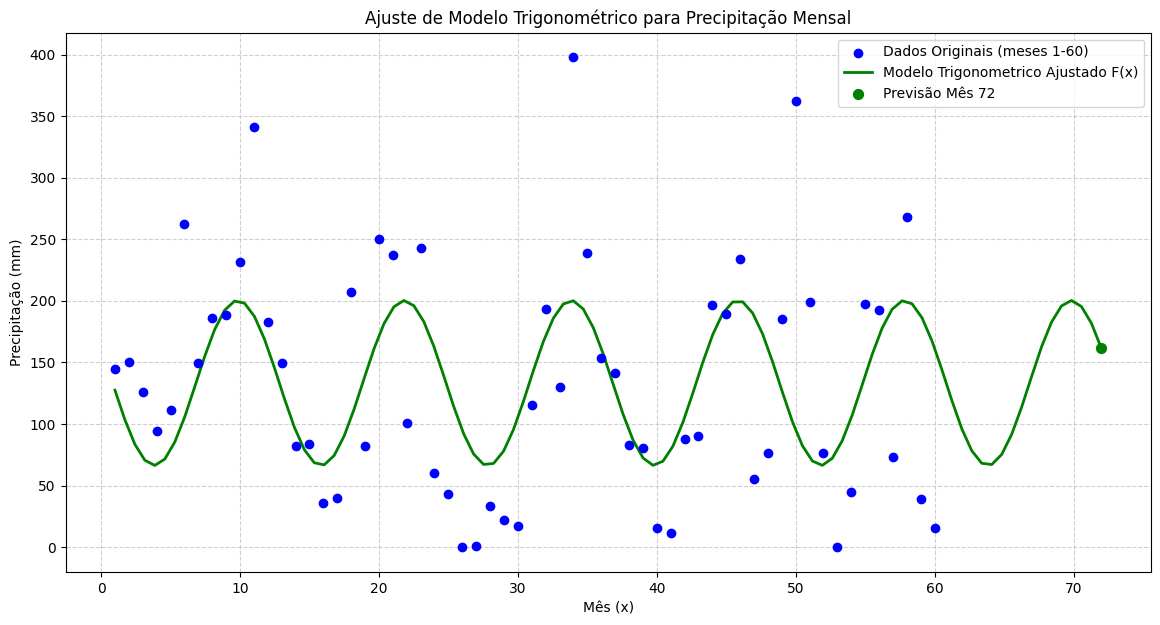

In [ ]:
#visualizar

x_curva = np.linspace(1,72,300)
y_curva = modelo_trigonometrico(x_curva, *params_otimos) # * para desempacotar

plt.figure(figsize=(14,7))
plt.scatter(x_dados,y_dados,label='Dados Originais (meses 1-60)', color = 'blue', zorder=5)
plt.plot(x_curva,y_curva, label='Modelo Trigonometrico Ajustado F(x)', color ='green', linewidth = 2)

plt.title('Ajuste de Modelo Trigonométrico para Precipitação Mensal')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

mes_futuro = 72
precipitacao_prevista = modelo_trigonometrico(mes_futuro,*params_otimos)
print(f"\n--- Previsão ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

plt.scatter(mes_futuro, precipitacao_prevista, color='green', marker='.', s=200, label=f'Previsão Mês {mes_futuro}', zorder=10)
plt.legend()
plt.show()

--- Previsão para o Mês 72 (para cada ordem) ---
Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm


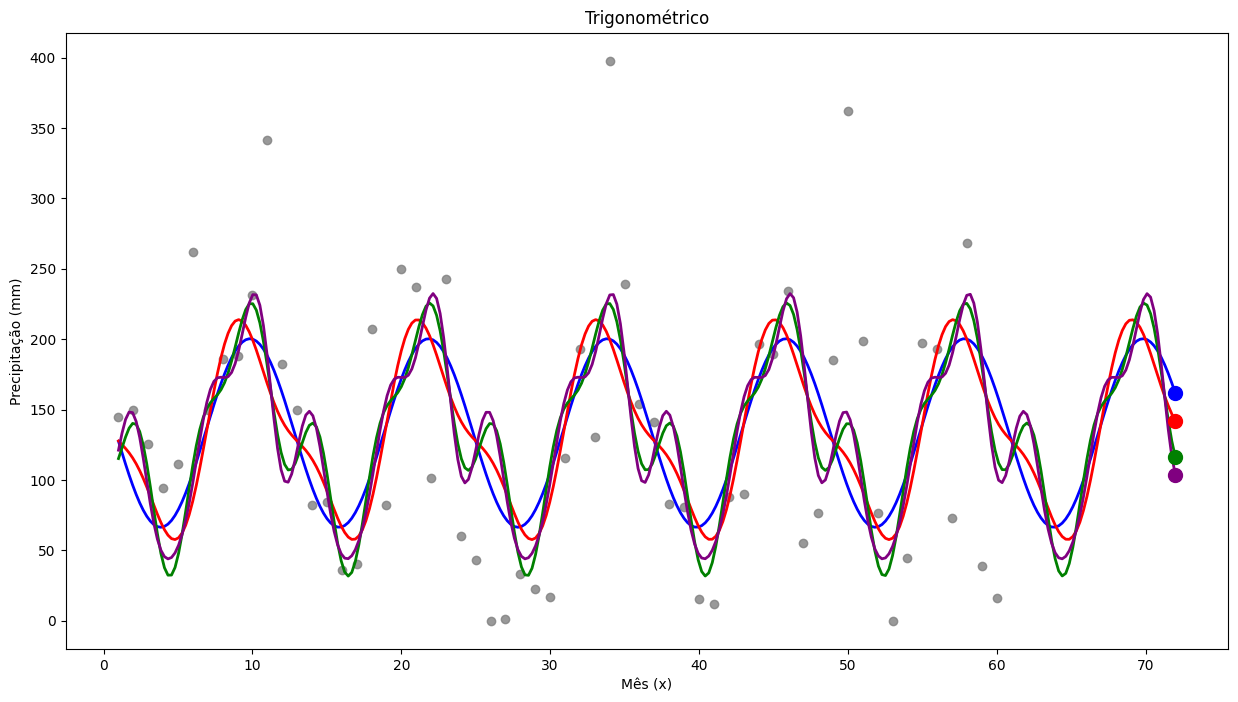

In [69]:
m = len(x_dados)

# --- A Função de Modelo Geral ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        termo_cos = Ak * np.cos(2 * np.pi * ordem_k * x / 12)
        termo_sin = Bk * np.sin(2 * np.pi * ordem_k * x / 12)
        y = y + termo_cos + termo_sin
    return y

# --- Loop para Testar Ordens e Mostrar Previsões ---
plt.figure(figsize=(15, 8))
plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.8)

print("--- Previsão para o Mês 72 (para cada ordem) ---")

# Lista de cores para as curvas e pontos
cores = ['blue', 'red', 'green', 'purple']

for i, ordem_n in enumerate(range(1, 5)):
    num_params = 1 + 2 * ordem_n
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem_n)
    
    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Plotar a curva do modelo
        x_curva = np.linspace(1, 72, 300)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        cor_atual = cores[i % len(cores)] # Seleciona a cor
        plt.plot(x_curva, y_curva, label=f'Ordem {ordem_n}', color=cor_atual, linewidth=2)
        
        # Calcular e mostrar a previsão para esta ordem
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem_n}: {precipitacao_prevista:.2f} mm")
        
        # Destacar o ponto da previsão no gráfico
        plt.scatter(mes_futuro, precipitacao_prevista, color=cor_atual, marker='o', s=100, zorder=10)

    except RuntimeError:
        print(f"Ordem {ordem_n}: Não foi possível ajustar o modelo.")

# --- Finalizar o gráfico ---
plt.title('Trigonométrico')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpolação polinomial -> não faz sentido pois explode

Ajustando um polinômio de grau 59...

--- Previsão com Interpolação Polinomial ---
A precipitação estimada para o mês 72 é: 1.085978e+15


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\3149034502.py:23: RankWarning: Polyfit may be poorly conditioned
  coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)


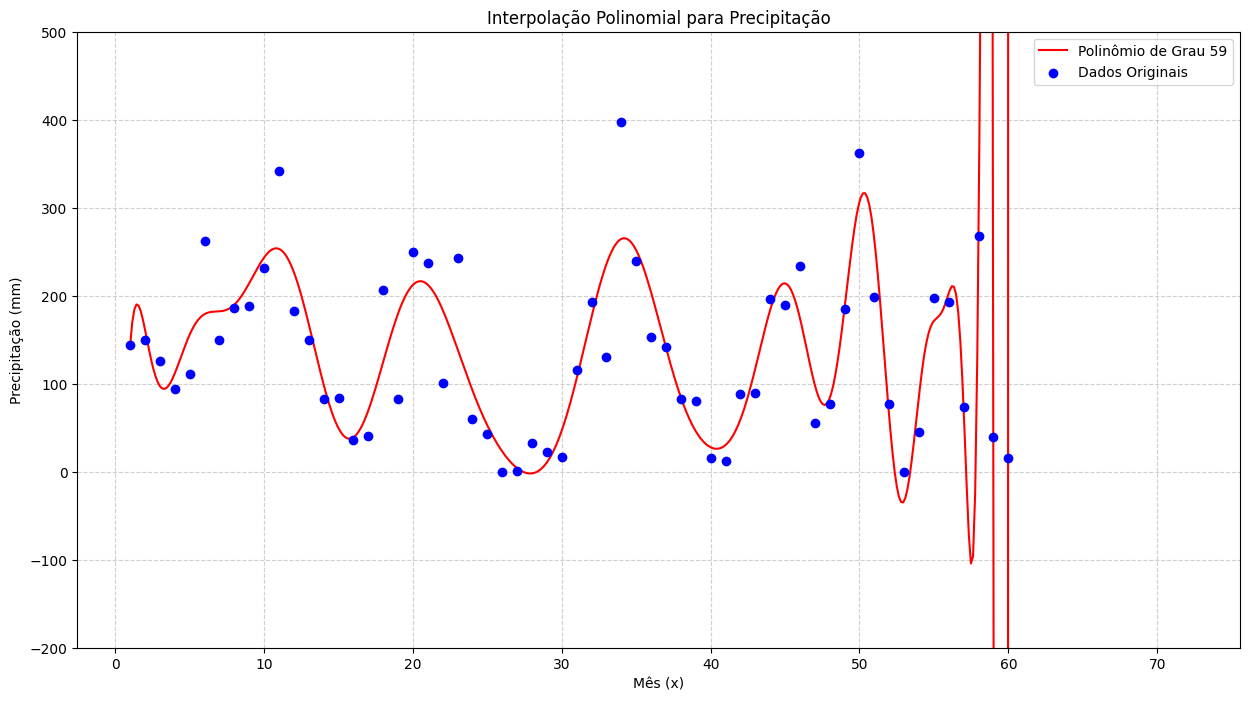

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Interpolação Polinomial ---
# Para 60 pontos, o grau do polinômio que passa por todos é 59.
grau_polinomio = 59

print(f"Ajustando um polinômio de grau {grau_polinomio}...")

# 1. Encontrar os coeficientes do polinômio
# A função pode emitir um aviso "Polyfit may be poorly conditioned", o que é esperado.
coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)

# 2. Criar a função polinomial a partir dos coeficientes
polinomio_interpolador = np.poly1d(coeficientes)

# 3. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = polinomio_interpolador(mes_futuro)

print(f"\n--- Previsão com Interpolação Polinomial ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}") # Usando notação científica

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 72, 500)
y_curva = polinomio_interpolador(x_curva)
plt.plot(x_curva, y_curva, label=f'Polinômio de Grau {grau_polinomio}', color='red')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial para Precipitação')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)

# ATENÇÃO: Vamos limitar o eixo Y para podermos ver os dados originais.
# A curva polinomial "explode" para valores muito altos/baixos.
plt.ylim(-200, 500) # Ajuste este limite para conseguir ver a curva vs. os pontos
plt.legend()
plt.show()

Lagrange => não faz sentido pois explode, obedece a todos os ruídos e, por isso, seu comportamento fora do intervalo dos dados é caótico e imprevisível.

Construindo o polinômio interpolador de Lagrange...

--- Previsão com Interpolação de Lagrange ---
A precipitação estimada para o mês 72 é: 9.090950e+39


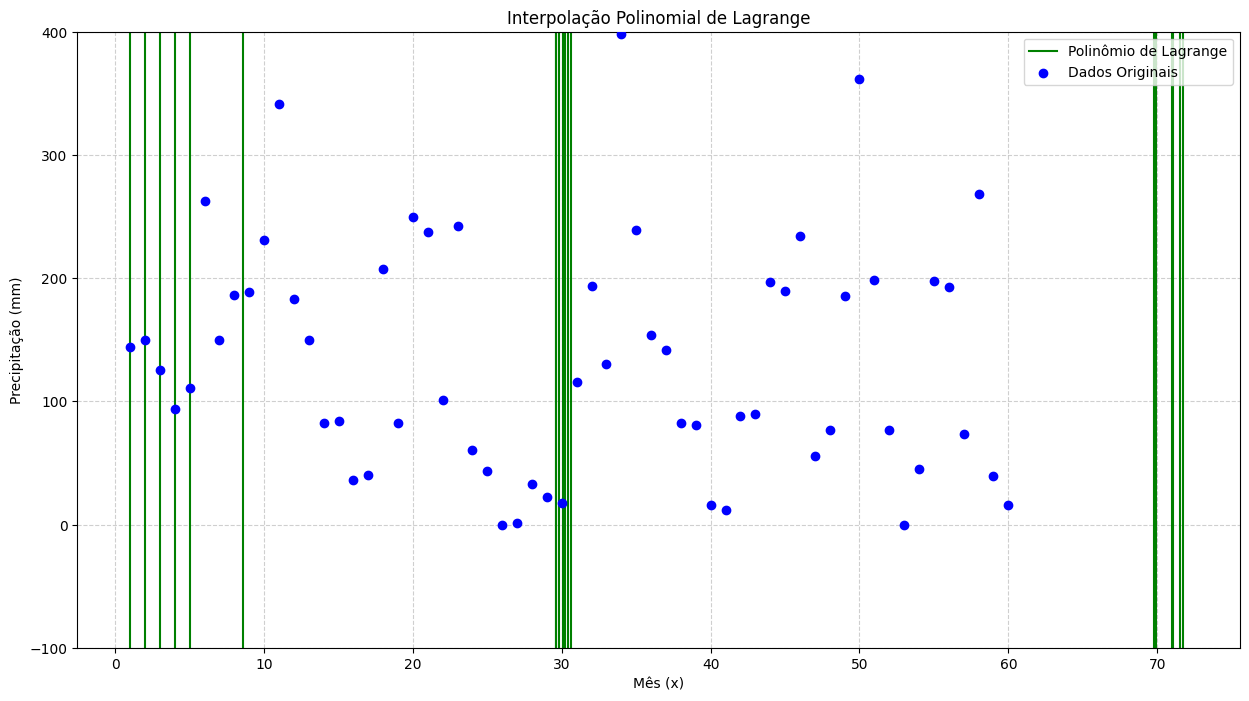

In [86]:
import numpy as np
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

print("Construindo o polinômio interpolador de Lagrange...")

# 1. A função lagrange já retorna o objeto de polinômio pronto para uso.
# É mais direto que o polyfit, que retorna apenas os coeficientes.
polinomio_lagrange = lagrange(x_dados, y_dados)

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = polinomio_lagrange(mes_futuro)

print(f"\n--- Previsão com Interpolação de Lagrange ---")
# O resultado será idêntico ao do polyfit, pois o polinômio interpolador é único.
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 72, 500)
y_curva = polinomio_lagrange(x_curva)
plt.plot(x_curva, y_curva, label='Polinômio de Lagrange', color='green')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial de Lagrange')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-200, 500) # Limitando o eixo Y para visualizar os dados
plt.legend()
plt.ylim(-100, 400)
plt.show()

Interpolação linear => Não faz sentido pois simplesmente conecta pontos de dados consecutivos com uma linha reta. O resultado não é uma única curva suave, mas uma série de segmentos de retas

Criando a função de interpolação linear...

--- Previsão com Interpolação Linear ---
A precipitação estimada para o mês 72 é: -262.60 mm


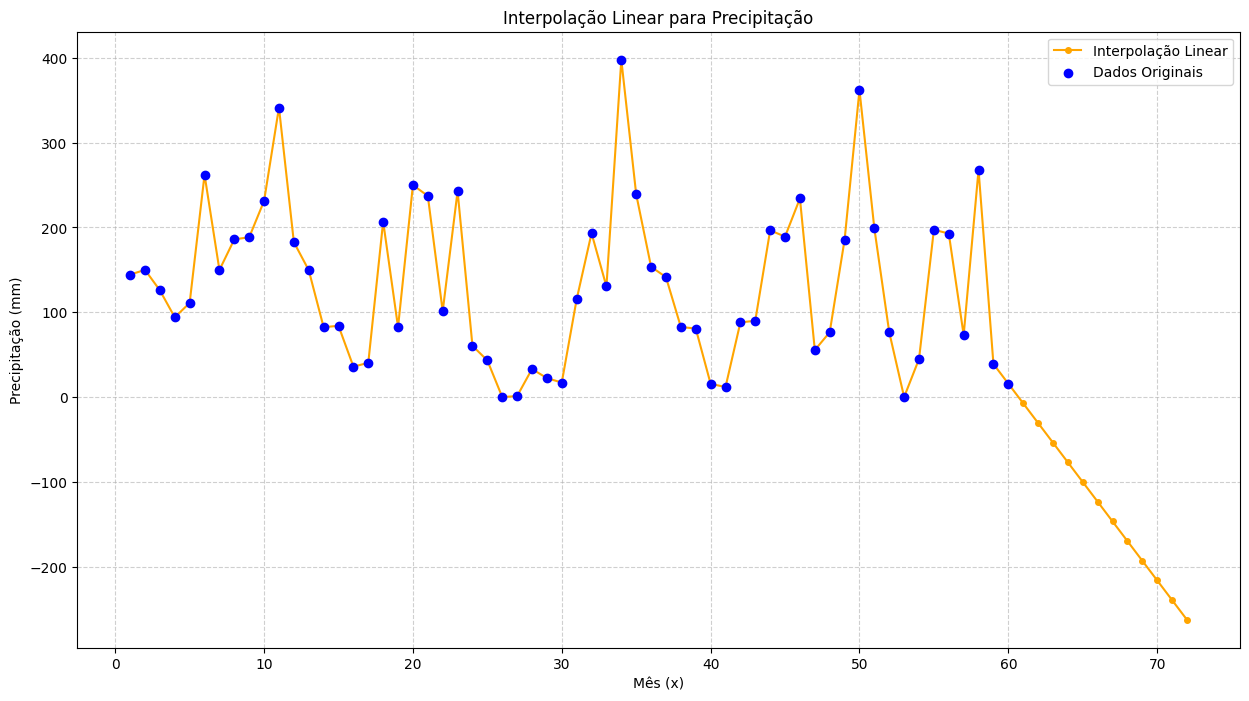

In [76]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

print("Criando a função de interpolação linear...")

# 1. Criar a função de interpolação
# 'kind='linear'' é o padrão, mas deixamos explícito.
# 'fill_value="extrapolate"' permite que a função faça previsões fora do intervalo [1, 60].
funcao_linear = interp1d(x_dados, y_dados, kind='linear', fill_value="extrapolate")

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = funcao_linear(mes_futuro)

print(f"\n--- Previsão com Interpolação Linear ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
# Usamos os dados originais para x para mostrar os segmentos de reta
x_curva = np.arange(1, 73) # Vai até o mês 72
y_curva = funcao_linear(x_curva)
plt.plot(x_curva, y_curva, label='Interpolação Linear', color='orange', marker='o', markersize=4)

# Plotar os dados originais
plt.scatter(x_dados, y_dados, color='blue', zorder=5, label='Dados Originais')

plt.title('Interpolação Linear para Precipitação')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Diferenças divididas => não faz sentido pois tambem explode, é uma aproximação exata


 O seu objetivo é a aproximação e extrapolação – encontrar uma tendência geral em dados "ruidosos" e prever o futuro. São objetivos conflitantes.

Calculando o polinômio via Diferenças Divididas de Newton...

--- Previsão com Diferenças Divididas de Newton ---
A precipitação estimada para o mês 72 é: 2.957245e+31


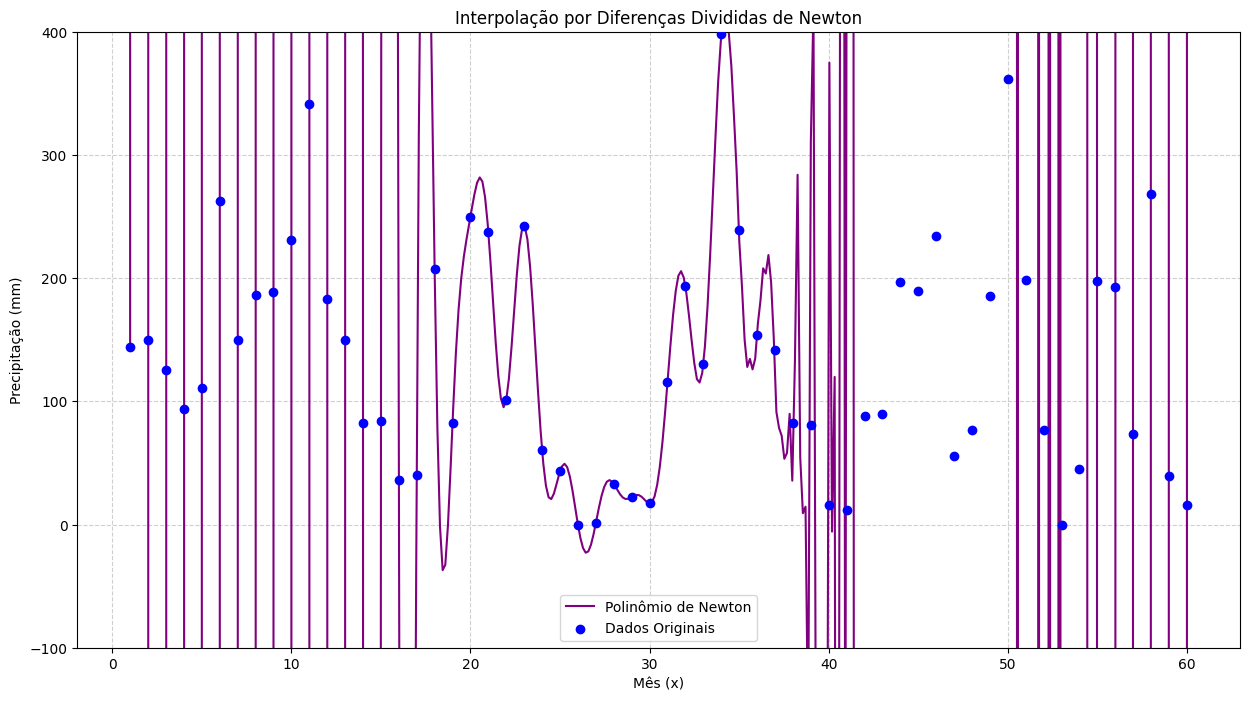

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Implementação do Método de Diferenças Divididas de Newton ---

def calcular_coeficientes(x, y):
    """
    Calcula os coeficientes (a diagonal da tabela de diferenças divididas).
    """
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y # A primeira coluna é y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :] # Retorna a primeira linha (c0, c1, c2, ...)

def avaliar_polinomio(coef, x_data, x_eval):
    """
    Avalia o polinômio na forma de Newton em um ponto x_eval.
    """
    n = len(coef) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

print("Calculando o polinômio via Diferenças Divididas de Newton...")

# 1. Calcular os coeficientes c0, c1, ...
coeficientes_newton = calcular_coeficientes(x_dados, y_dados)

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = avaliar_polinomio(coeficientes_newton, x_dados, mes_futuro)

print(f"\n--- Previsão com Diferenças Divididas de Newton ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Avaliar o polinômio em vários pontos para plotar a curva
x_curva = np.linspace(1, 60, 400) # Evitamos extrapolar no plot para não distorcer a escala
y_curva = [avaliar_polinomio(coeficientes_newton, x_dados, x) for x in x_curva]
plt.plot(x_curva, y_curva, label='Polinômio de Newton', color='purple')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação por Diferenças Divididas de Newton')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(-100, 400)
plt.show()

Formula de Newtonv-> igual diferenças divididas

Executando o método de interpolação de Newton...

A previsão para o mês 72 é: 2.957245e+31


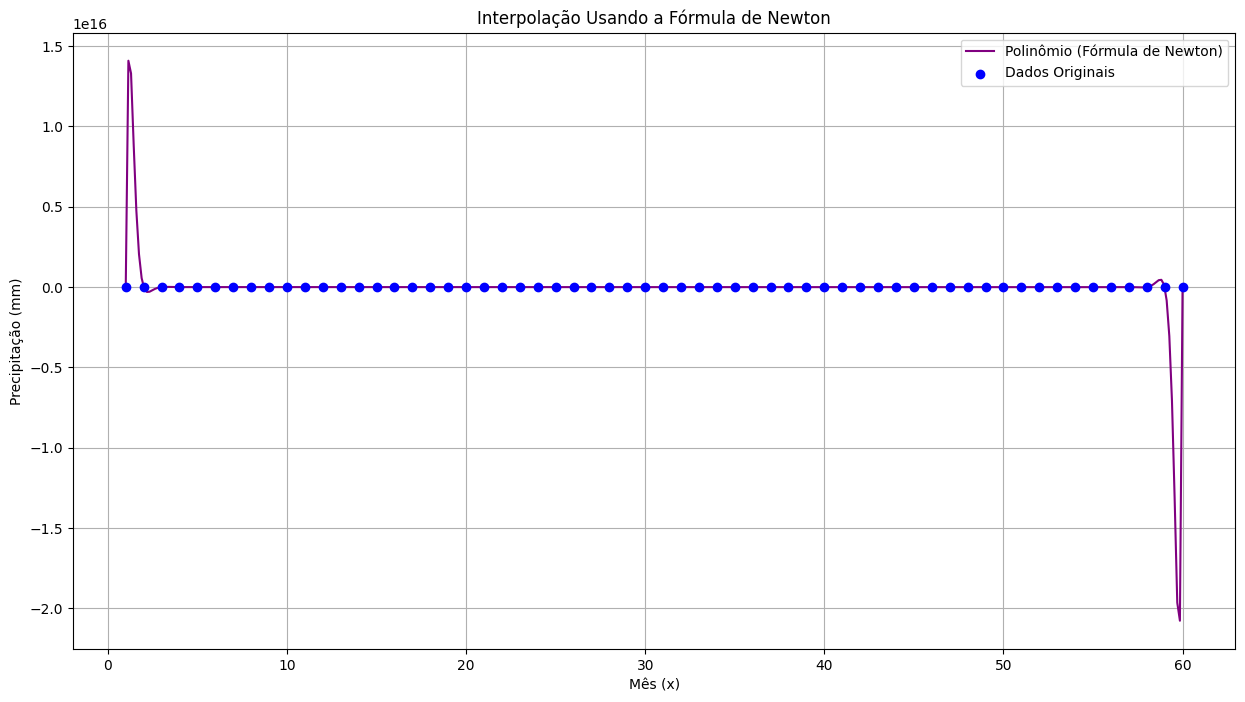

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# ==============================================================================
# PARTE 1: CALCULANDO OS "INGREDIENTES" (AS DIFERENÇAS DIVIDIDAS)
# ==============================================================================
def calcular_coeficientes_newton(x, y):
    """
    Esta função calcula os coeficientes c0, c1, c2, ... 
    que são as próprias diferenças divididas.
    """
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :] # Os coeficientes são a primeira linha da tabela

# ==============================================================================
# PARTE 2: USANDO A "RECEITA" (A FÓRMULA DE NEWTON)
# ==============================================================================
def avaliar_com_formula_newton(coef, x_data, x_eval):
    """
    Esta função usa a Fórmula de Newton para montar o polinômio e calcular 
    seu valor em um ponto específico (x_eval), usando os coeficientes da Parte 1.
    P(x) = c0 + c1(x-x0) + c2(x-x0)(x-x1) + ...
    """
    n = len(coef) - 1
    p = coef[n] # Começa com o último coeficiente
    for k in range(1, n + 1):
        # Itera de trás para frente, construindo o polinômio
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

# --- Executando o Processo Completo ---
print("Executando o método de interpolação de Newton...")

# 1. Obter os ingredientes (Diferenças Divididas)
coeficientes = calcular_coeficientes_newton(x_dados, y_dados)

# 2. Usar a receita (Fórmula de Newton) para prever o mês 72
mes_futuro = 72
precipitacao_prevista = avaliar_com_formula_newton(coeficientes, x_dados, mes_futuro)

print(f"\nA previsão para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# 3. Usar a receita novamente para gerar o gráfico
x_curva = np.linspace(1, 60, 400)
y_curva = [avaliar_com_formula_newton(coeficientes, x_dados, x) for x in x_curva]

# --- Visualização ---
plt.figure(figsize=(15, 8))
plt.plot(x_curva, y_curva, label='Polinômio (Fórmula de Newton)', color='purple')
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)
plt.title('Interpolação Usando a Fórmula de Newton')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True)
plt.legend()
plt.show()